In [1]:
import pandas as pd


df = pd.read_json(
    "../data/processed/Movies_Features.json"
)

print(df.shape)
print(df.head())


features = [
    "runtime",
    "budget",
    "revenue",
    "popularity",
    "vote_average",
    "num_genres",
    "num_keywords",
    "release_year"
]

X = df[features].copy()

print(X.isnull().sum())

X["release_year"] = X["release_year"].fillna(
    X["release_year"].median()
)

X["runtime"] = X["runtime"].fillna(
    X["runtime"].median()
)

print(X.isnull().sum())

print("Clustering data shape:", X.shape)

(2740, 20)
   movie_id                      title  \
0    969681  Spider-Man: Brand New Day   
1   1423191              Resident Evil   
2   1101383      The End of Oak Street   
3   1204680            Coyote vs. Acme   
4   1368337                The Odyssey   

                                            overview  release_date  runtime  \
0  Fighting crime full-time as Spider-Man in a wo...  1.785283e+12      145   
1  Medical courier Bryan unwittingly finds himsel...  1.789517e+12       95   
2  After a mysterious cosmic event rips Oak Stree...  1.786493e+12      100   
3  After Acme products fail him one too many time...  1.786925e+12      103   
4  Odysseus, the legendary King of Ithaca, embark...  1.784074e+12      173   

  original_language                                genres  \
0                en  [Science Fiction, Action, Adventure]   
1                en  [Horror, Science Fiction, Adventure]   
2                en  [Science Fiction, Mystery, Thriller]   
3                

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original data:")
print(X.head())

print("\nScaled data:")
print(X_scaled[:5])

Original data:
   runtime     budget     revenue  popularity  vote_average  num_genres  \
0      145  225000000  2505477000         687             7           3   
1       95   75000000   245400000         407             7           3   
2      100   80000000   120363694         392             7           3   
3      103   72000000    88043208         355             7           3   
4      173  250000000  1767464000         366             8           3   

   num_keywords  release_year  
0            19        2026.0  
1            16        2026.0  
2            16        2026.0  
3            13        2026.0  
4            18        2026.0  

Scaled data:
[[ 1.32730585  2.78492239  8.55256011 24.36556712  0.6020489   0.28106472
   0.46749789  1.02157974]
 [-0.63958365  0.37875462  0.23851459 14.13714874  0.6020489   0.28106472
   0.12796505  1.02157974]
 [-0.4428947   0.45896021 -0.22145095 13.58919775  0.6020489   0.28106472
   0.12796505  1.02157974]
 [-0.32488133  0.33063126

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 9)

inertia_values = []
silhouette_values = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = kmeans.fit_predict(
        X_scaled
    )

    inertia = kmeans.inertia_

    silhouette = silhouette_score(
        X_scaled,
        clusters
    )

    inertia_values.append(inertia)
    silhouette_values.append(silhouette)

    print(
        "K:", k,
        "| Inertia:", inertia,
        "| Silhouette:", silhouette
    )

results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values,
    "Silhouette": silhouette_values
})

print(results)

K: 2 | Inertia: 18361.68696627077 | Silhouette: 0.2537528979708146
K: 3 | Inertia: 16039.430963076218 | Silhouette: 0.16421294177071075
K: 4 | Inertia: 14487.711523631218 | Silhouette: 0.1748892177651384
K: 5 | Inertia: 13132.114645899373 | Silhouette: 0.19595712255562864
K: 6 | Inertia: 11971.883955957539 | Silhouette: 0.159470572605781
K: 7 | Inertia: 11143.130156989268 | Silhouette: 0.16333365742979675
K: 8 | Inertia: 10491.461076823292 | Silhouette: 0.15810966371853769
   K       Inertia  Silhouette
0  2  18361.686966    0.253753
1  3  16039.430963    0.164213
2  4  14487.711524    0.174889
3  5  13132.114646    0.195957
4  6  11971.883956    0.159471
5  7  11143.130157    0.163334
6  8  10491.461077    0.158110


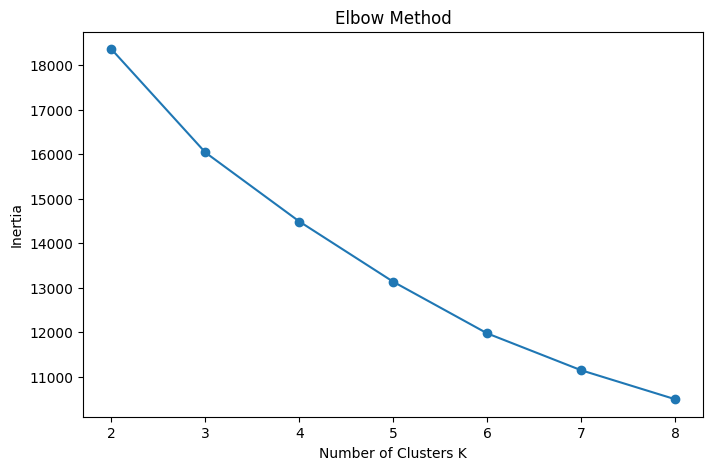

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters K")
plt.ylabel("Inertia")

plt.show()

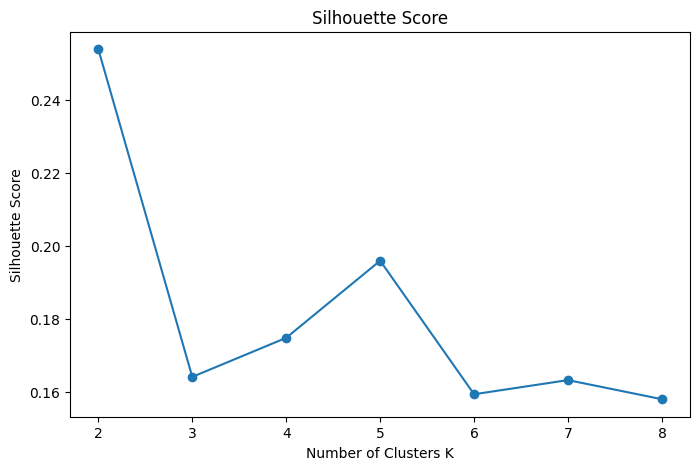

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_values,
    marker="o"
)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters K")
plt.ylabel("Silhouette Score")

plt.show()

In [6]:
best_index = silhouette_values.index(
    max(silhouette_values)
)

best_k = list(k_values)[best_index]

print("Best K:", best_k)
print(
    "Best Silhouette Score:",
    max(silhouette_values)
)

Best K: 2
Best Silhouette Score: 0.2537528979708146


In [7]:

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)


clusters = final_kmeans.fit_predict(
    X_scaled
)

df["cluster"] = clusters


print(
    df[
        [
            "title",
            "cluster"
        ]
    ]
)

                           title  cluster
0      Spider-Man: Brand New Day        1
1                  Resident Evil        1
2          The End of Oak Street        1
3                Coyote vs. Acme        1
4                    The Odyssey        1
...                          ...      ...
2735             Ghost Elephants        0
2736                   Eddington        0
2737  The Taking of Pelham 1 2 3        0
2738                 The Wolfman        0
2739  Ace Ventura: Pet Detective        0

[2740 rows x 2 columns]


In [8]:
cluster_counts = df["cluster"].value_counts()

print(cluster_counts)

cluster
0    2135
1     605
Name: count, dtype: int64


In [9]:
cluster_profiles = df.groupby(
    "cluster"
)[features].mean()

print(cluster_profiles)

            runtime        budget       revenue  popularity  vote_average  \
cluster                                                                     
0        107.037939  2.596950e+07  8.647591e+07   17.243091      6.207026   
1        126.153719  1.410903e+08  5.125874e+08   29.727273      6.497521   

         num_genres  num_keywords  release_year  
cluster                                          
0          2.563466     13.918501   2009.774602  
1          3.294215     18.224793   2013.328926  


In [10]:
print("Release year description:")
print(df["release_year"].describe())

print("\nFirst release years:")
print(df["release_year"].head(20))

print("\nFirst release dates:")
print(df["release_date"].head(20))

Release year description:
count    2739.000000
mean     2010.559693
std        15.118294
min      1933.000000
25%      2003.000000
50%      2014.000000
75%      2023.000000
max      2028.000000
Name: release_year, dtype: float64

First release years:
0     2026.0
1     2026.0
2     2026.0
3     2026.0
4     2026.0
5     2026.0
6     2026.0
7     2026.0
8     2026.0
9     2026.0
10    2026.0
11    2026.0
12    2026.0
13    2026.0
14    2026.0
15    2026.0
16    2026.0
17    2026.0
18    2026.0
19    2019.0
Name: release_year, dtype: float64

First release dates:
0     1.785283e+12
1     1.789517e+12
2     1.786493e+12
3     1.786925e+12
4     1.784074e+12
5     1.790122e+12
6     1.793232e+12
7     1.787098e+12
8     1.779322e+12
9     1.789430e+12
10    1.788998e+12
11    1.789776e+12
12    1.781654e+12
13    1.790294e+12
14    1.788134e+12
15    1.790035e+12
16    1.778630e+12
17    1.783469e+12
18    1.784678e+12
19    1.556064e+12
Name: release_date, dtype: float64


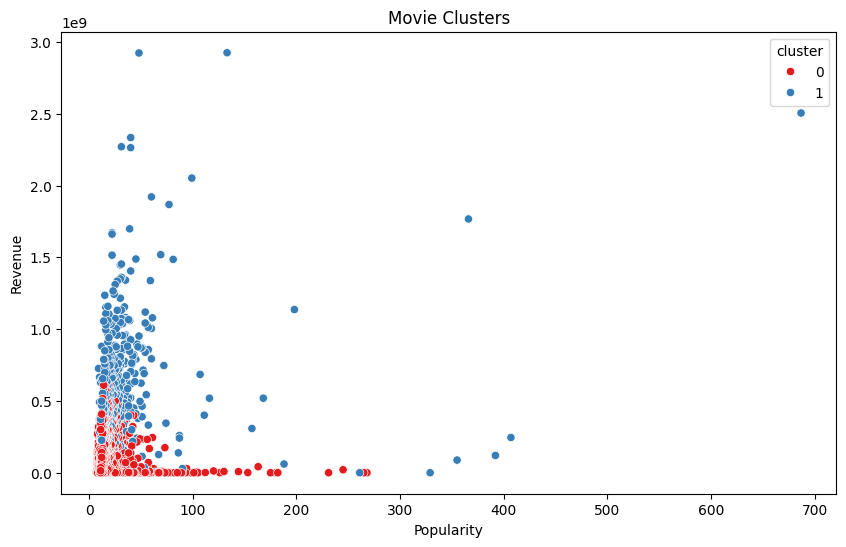

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="popularity",
    y="revenue",
    hue="cluster",
    palette="Set1"
)

plt.title("Movie Clusters")
plt.xlabel("Popularity")
plt.ylabel("Revenue")

plt.show()

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_scaled
)

centroids_pca = pca.transform(
    final_kmeans.cluster_centers_
)

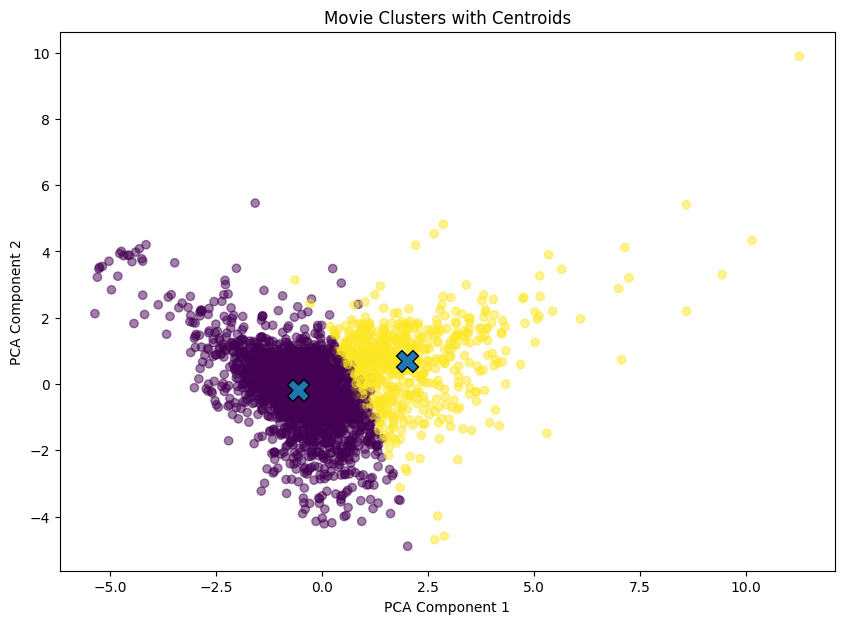

In [15]:
plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"],
    alpha=0.5
)


# Centroids
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=250,
    edgecolors="black"
)


plt.title(
    "Movie Clusters with Centroids"
)

plt.xlabel(
    "PCA Component 1"
)

plt.ylabel(
    "PCA Component 2"
)

plt.show()